# DETEKSI TEPI (CANNY VS SOBEL) DAN CONTOUR

In [3]:
%matplotlib inline

In [4]:
!pip install opencv-python numpy matplotlib scikit-image

In [5]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'alam.jpeg', 'arasjamak.jpeg', 'daun.jpg', 'Laporan2_202431114_Erol Ahyan Abrizam Hasibuan_PCDH.ipynb']


In [7]:
!pip install scikit-image

# Setup Library

In [12]:
# 202431114_Erol Ahyan Abrizam Hasibuan

%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Membaca Gambar

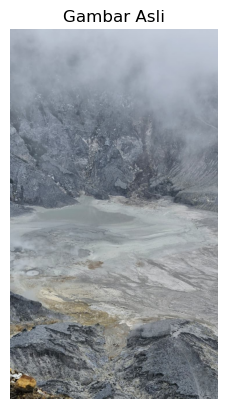

In [13]:
# 202431114_Erol Ahyan Abrizam Hasibuan

img = cv2.imread("alam.jpeg")

if img is None:
    raise FileNotFoundError("File alam.jpg tidak ditemukan")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")
plt.show()

# Grayscale

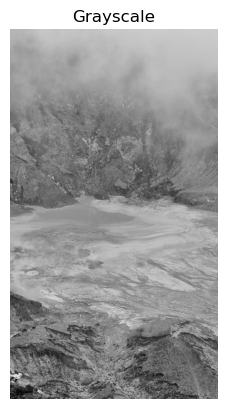

In [14]:
# 202431114_Erol Ahyan Abrizam Hasibuan

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

# Canny

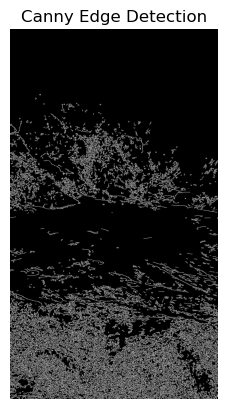

In [16]:
# 202431114_Erol Ahyan Abrizam Hasibuan

canny = cv2.Canny(gray, 100, 200)

plt.imshow(canny, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

# Sobel

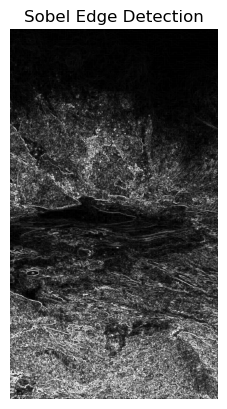

In [17]:
# 202431114_Erol Ahyan Abrizam Hasibuan

sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, 3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, 3)

sobel = cv2.magnitude(sobelx, sobely)
sobel = cv2.convertScaleAbs(sobel)

plt.imshow(sobel, cmap="gray")
plt.title("Sobel Edge Detection")
plt.axis("off")
plt.show()

# Perbandingan

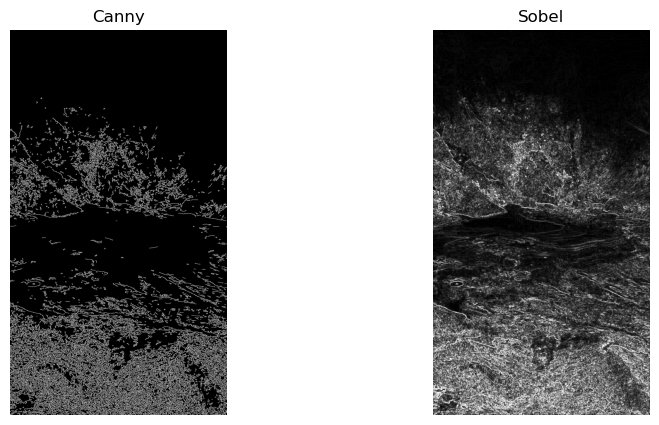

In [18]:
# 202431114_Erol Ahyan Abrizam Hasibuan

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(canny, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sobel, cmap="gray")
plt.title("Sobel")
plt.axis("off")

plt.show()

# Contour

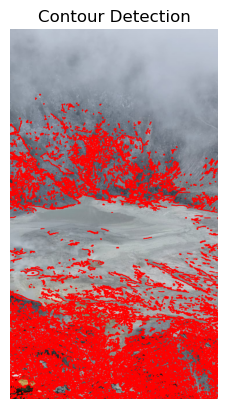

Jumlah Contour: 3809


In [19]:
# 202431114_Erol Ahyan Abrizam Hasibuan

result = cv2.findContours(canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = result[-2]

contour_img = img_rgb.copy()

cv2.drawContours(contour_img, contours, -1, (255, 0, 0), 2)

plt.imshow(contour_img)
plt.title("Contour Detection")
plt.axis("off")
plt.show()

print("Jumlah Contour:", len(contours))

# Ringkasan

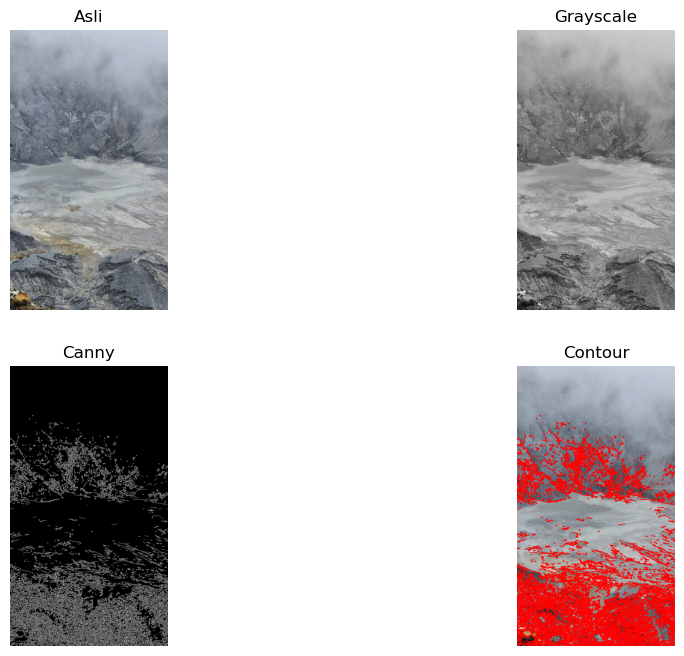

In [20]:
# 202431114_Erol Ahyan Abrizam Hasibuan

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img_rgb)
plt.title("Asli")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(canny, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(contour_img)
plt.title("Contour")
plt.axis("off")

plt.show()

# (DWI ARAS & MULTI OTSU)

In [21]:
# 202431114_Erol Ahyan Abrizam Hasibuan

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_multiotsu

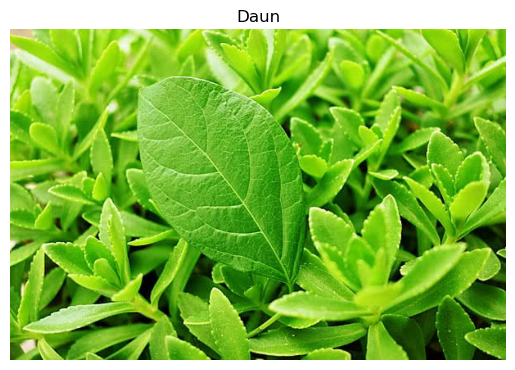

In [22]:
# 202431114_Erol Ahyan Abrizam Hasibuan

img = cv2.imread("daun.jpg")

if img is None:
    raise FileNotFoundError("File daun.jpg tidak ditemukan")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Daun")
plt.axis("off")
plt.show()

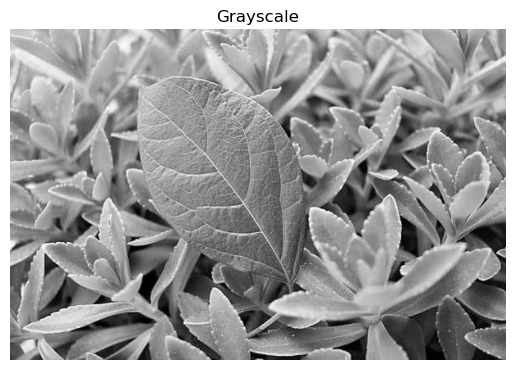

In [23]:
# 202431114_Erol Ahyan Abrizam Hasibuan

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

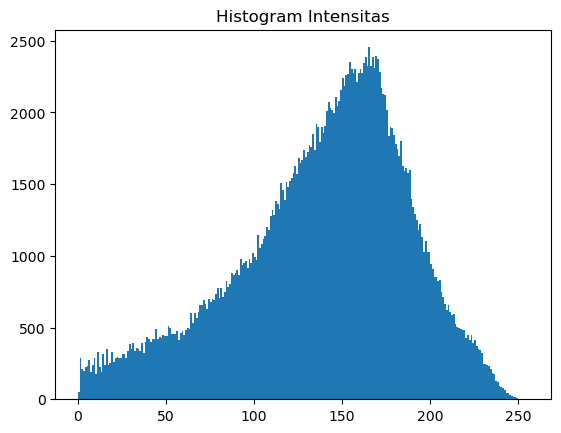

In [24]:
# 202431114_Erol Ahyan Abrizam Hasibuan

plt.hist(gray.ravel(), bins=256, range=[0,256])
plt.title("Histogram Intensitas")
plt.show()

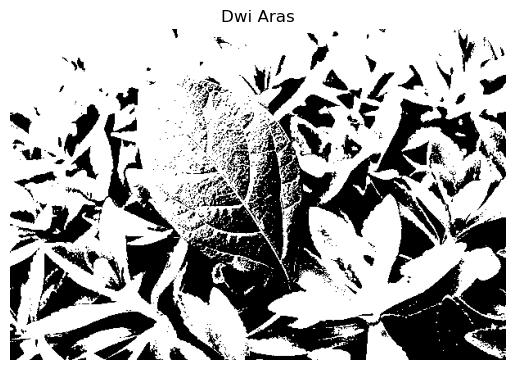

In [25]:
# 202431114_Erol Ahyan Abrizam Hasibuan

_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap="gray")
plt.title("Dwi Aras")
plt.axis("off")
plt.show()

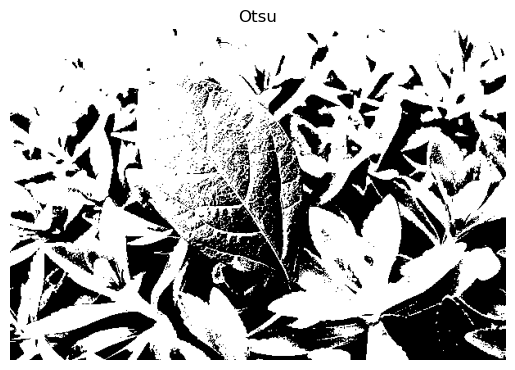

In [26]:
# 202431114_Erol Ahyan Abrizam Hasibuan

_, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(otsu, cmap="gray")
plt.title("Otsu")
plt.axis("off")
plt.show()

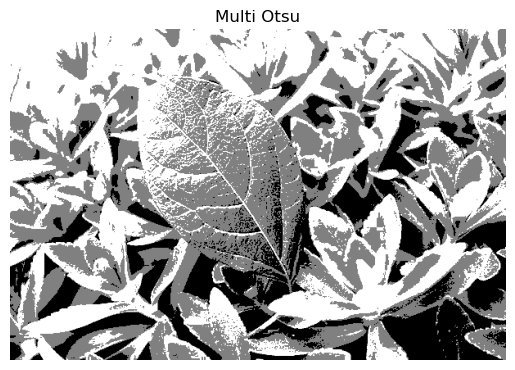

Threshold: [ 94 156]


In [27]:
# 202431114_Erol Ahyan Abrizam Hasibuan

thresholds = threshold_multiotsu(gray, classes=3)
regions = np.digitize(gray, bins=thresholds)

plt.imshow(regions, cmap="gray")
plt.title("Multi Otsu")
plt.axis("off")
plt.show()

print("Threshold:", thresholds)

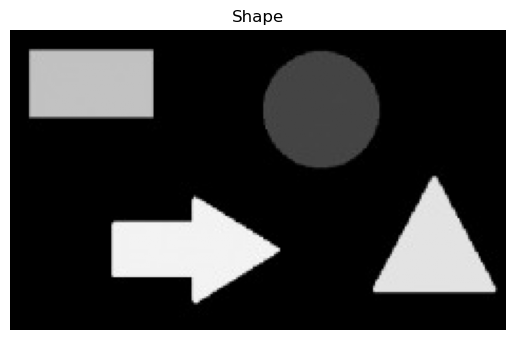

In [29]:
# 202431114_Erol Ahyan Abrizam Hasibuan

shape = cv2.imread("arasjamak.jpeg")

if shape is None:
    raise FileNotFoundError("File arasjamak.jpeg tidak ditemukan")

shape_gray = cv2.cvtColor(shape, cv2.COLOR_BGR2GRAY)

plt.imshow(shape_gray, cmap="gray")
plt.title("Shape")
plt.axis("off")
plt.show()

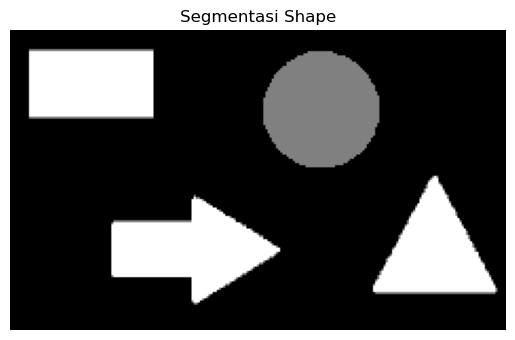

In [30]:
# 202431114_Erol Ahyan Abrizam Hasibuan

thresholds_shape = threshold_multiotsu(shape_gray, classes=3)
regions_shape = np.digitize(shape_gray, bins=thresholds_shape)

plt.imshow(regions_shape, cmap="gray")
plt.title("Segmentasi Shape")
plt.axis("off")
plt.show()

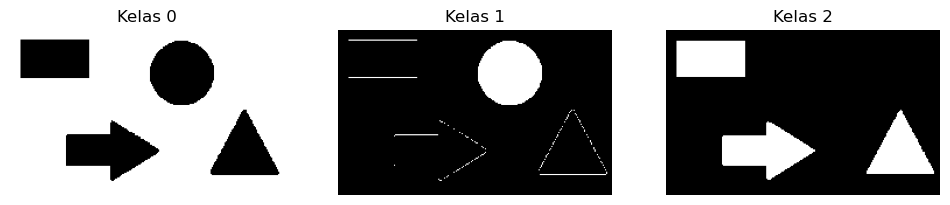

In [31]:
# 202431114_Erol Ahyan Abrizam Hasibuan

kelas0 = (regions_shape == 0).astype(np.uint8) * 255
kelas1 = (regions_shape == 1).astype(np.uint8) * 255
kelas2 = (regions_shape == 2).astype(np.uint8) * 255

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(kelas0, cmap="gray")
plt.title("Kelas 0")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(kelas1, cmap="gray")
plt.title("Kelas 1")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(kelas2, cmap="gray")
plt.title("Kelas 2")
plt.axis("off")

plt.show()